In [2]:
print("lab-4")

lab-4


In [3]:
import pandas as pd
df = pd.read_csv(r"C:\Users\CSE Lab\OneDrive - Amrita Vishwa Vidyapeetham\Desktop\comp_database.csv")
print(df)

    RID         Age  Income Student Credit_rating class:buys_comp
0     1       Youth    High      No          Fair              No
1     2       Youth    High      No     Excellent              No
2     3  Middle Age    High      No          Fair             Yes
3     4      Senior  Medium      No          Fair             Yes
4     5      Senior     Low     Yes          Fair             Yes
5     6      Senior     Low     Yes     Excellent              No
6     7  Middle Age     Low     Yes     Excellent             Yes
7     8       Youth  Medium      No          Fair              No
8     9       Youth     Low     Yes          Fair             Yes
9    10      Senior  Medium     Yes          Fair             Yes
10   11       Youth  Medium     Yes     Excellent             Yes
11   12  Middle Age  Medium      No     Excellent             Yes
12   13  Middle Age    High     Yes          Fair             Yes
13   14      Senior  Medium      No     Excellent              No



Encoded Dataset:
    RID  Age  Income  Student  Credit_rating  class:buys_comp
0     0    2       0        0              1                0
1     1    2       0        0              0                0
2     2    0       0        0              1                1
3     3    1       2        0              1                1
4     4    1       1        1              1                1
5     5    1       1        1              0                0
6     6    0       1        1              0                1
7     7    2       2        0              1                0
8     8    2       1        1              1                1
9     9    1       2        1              1                1
10   10    2       2        1              0                1
11   11    0       2        0              0                1
12   12    0       0        1              1                1
13   13    1       2        0              0                0

Accuracy:
0.4

Actual Values:
[1, 0, 1, 1, 1]

Pred

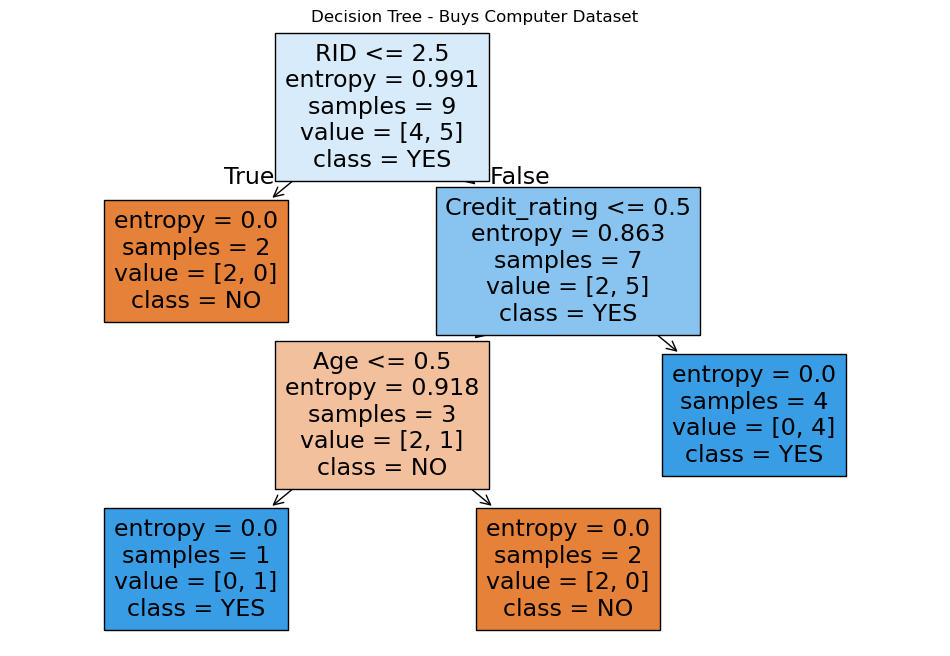

In [4]:
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

encoder = LabelEncoder()

for col in df.columns:
    df[col] = encoder.fit_transform(df[col])

print("\nEncoded Dataset:")
print(df)

X = df.drop("class:buys_comp", axis=1)
y = df["class:buys_comp"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)


# Create Decision Tree Model
model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=1
)


# Train model
model.fit(X_train, y_train)


# Prediction
y_pred = model.predict(X_test)


# Accuracy
print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))


print("\nActual Values:")
print(list(y_test))

print("\nPredicted Values:")
print(list(y_pred))


# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# Display Decision Tree
plt.figure(figsize=(12,8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["NO","YES"],
    filled=True
)

plt.title("Decision Tree - Buys Computer Dataset")
plt.show()